## TODO:  HEADER

In [ ]:
%load_ext autoreload
%autoreload 2

import nltk

nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')

import umap
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.encoders import *
from utils.preprocess import text_cleaner, pipeline
from utils.utils import visualize_dimensionality_reduction # TODO: move funcs from encoder checks here

from lingua import LanguageDetectorBuilder
from deep_translator import GoogleTranslator
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, recall_score
from sklearn.model_selection import ParameterSampler

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
c:\Users\egorm\miniconda3\envs\tm_masters\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
STOPWORDS = set(stopwords.words("English")).difference({"up", "down", "above", "below", "under", 
                                                        "over", "more", "less", "against", "but", 
                                                        "not", "no"})
SEED = 42

# EDA

In [3]:
train_full = pd.read_csv(r"data/train.csv")
train, validation = train_test_split(train_full, 
                                     test_size=0.2, 
                                     stratify=train_full.label,
                                     random_state=SEED
                                     )
test = pd.read_csv(r"data/test.csv", index_col=0)
display(train.sample(3))
display(validation.sample(3))
test.sample(3)

,text,label
1324,Bombardier Global 7500 Aircraft Receives Prest...,2
1416,Dragonfly collaborates with Abbvie for autoimm...,2
5009,Ray Dalio fires back over hedge fund's reporte...,2


,text,label
6839,Nasdaq at record high as investors look past c...,1
8448,DFND,2
555,"Fed says Powell met with Trump, Mnuchin on Mon...",2


,text
id,
2204,The New England Patriots admitted that a crew ...
1764,Oliver has had this figured out for months.
2061,Waiting for your Equifax settlement cash? Don’...


## general

In [4]:
display(train.describe())
train.describe(include="str")

,label
count,7634.000000
mean,1.496201
std,0.743229
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,2.000000


,text
count,7634
unique,7634
top,Nasdaq prices 600M of 0.875% senior notes
freq,1


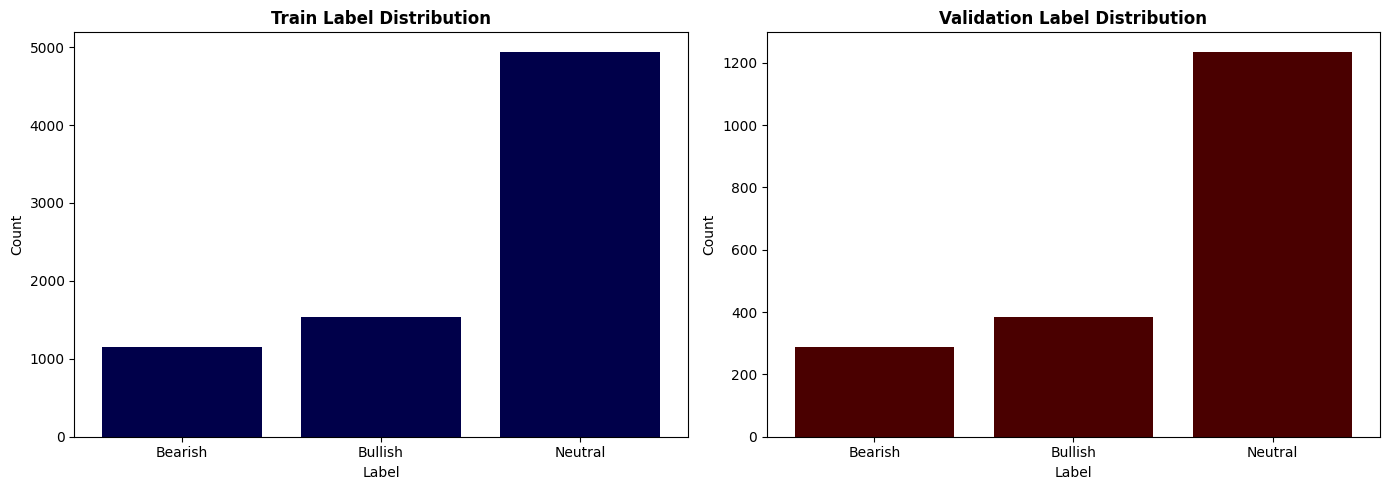

In [5]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(x = ["Bearish", "Bullish", "Neutral"],
        height=train.groupby("label")["text"].count().to_list(), # order by 0, 1, 2
        color="#00004A",
        )

ax[1].bar(x = ["Bearish", "Bullish", "Neutral"],
        height=validation.groupby("label")["text"].count().to_list(), # order by 0, 1, 2
        color="#4A0000",
        )

ax[0].set_xlabel("Label")
ax[0].set_ylabel("Count")
ax[0].set_title(
    "Train Label Distribution", fontweight="bold"
)

ax[1].set_xlabel("Label")
ax[1].set_ylabel("Count")
ax[1].set_title(
    "Validation Label Distribution", fontweight="bold"
)

plt.tight_layout()
plt.savefig(r"plots/correct_split.png")
plt.show()

## Text Overview

### Raw

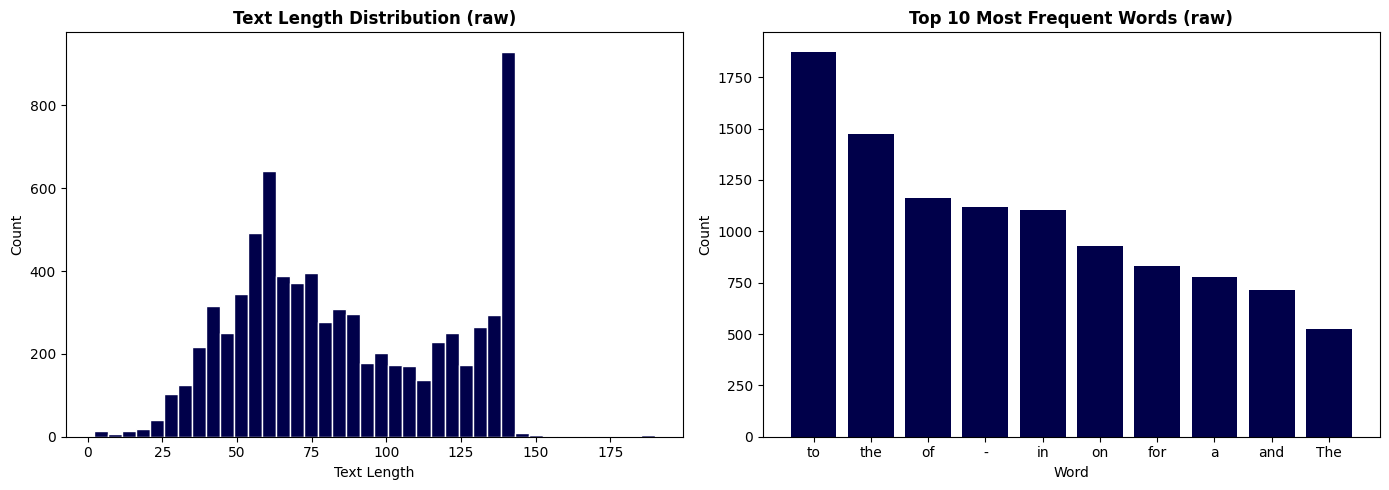

In [6]:
freq_raw = pd.Series(' '.join(train['text']).split()).value_counts()

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].hist(
         train.text.str.len(),
         bins=40,
         color="#00004A",
         edgecolor="white"
         )

ax[1].bar(freq_raw.head(10).index, freq_raw.head(10).values, color="#00004A")

ax[0].set_xlabel("Text Length")
ax[0].set_ylabel("Count")
ax[0].set_title("Text Length Distribution (raw)", fontweight="bold")
ax[1].set_xlabel("Word")
ax[1].set_ylabel("Count")
ax[1].set_title("Top 10 Most Frequent Words (raw)", fontweight="bold")
plt.tight_layout()
plt.savefig(r"plots/raw_distributions.png")
plt.show()

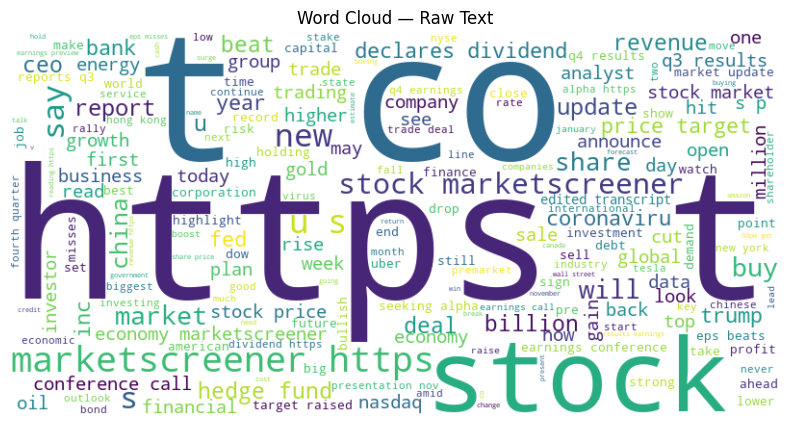

In [7]:
raw_text = ' '.join(train['text']).lower()
raw_wc = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Raw Text')
plt.savefig(r"plots/raw_wordcloud.png")
plt.show()

### Cleaning

In [8]:
train["text_clean"] = text_cleaner(train.text)
validation["text_clean"] = text_cleaner(validation.text)

display(train.sample(5))
validation.sample(5)

,text,label,text_clean
443,Asset Allocation Committee Outlook 2Q2020 | Co...,2,asset allocation committee outlook 2q2020 cont...
3823,"Fifteen days ago, the S&P 500 was mired in a b...",1,fifteen days ago the s p 500 was mired in a be...
3746,Highlight: “There’s going to be a bloodbath in...,0,highlight there is going to be a bloodbath in ...
7487,$AWK - American Water CEO Story to retire in A...,2,STOCK american water ceo story to retire in ap...
1864,SEBI Issues Performance Benchmarking Guideline...,2,sebi issues performance benchmarking guideline...


,text,label,text_clean
3528,"Toyota lifts annual profit forecast, looking a...",1,toyota lifts annual profit forecast looking at...
6538,Mexico Official Complains About 3-Way Trade De...,2,mexico official complains about 3 way trade de...
5127,Taiwan says it will help Hong Kong if violence...,2,taiwan says it will help hong kong if violence...
8879,We're A Little Worried About Graphite One's (C...,2,we are a little worried about graphite one cve...
1100,$FATE: Fate Therapeutics presents new preclini...,2,STOCK fate therapeutics presents new preclinic...


In [9]:
detector = LanguageDetectorBuilder.from_all_languages().build()

languages_train = detector.detect_languages_in_parallel_of(train.text_clean)
train["language"] = [lang.name.lower() if lang else None for lang in languages_train]

languages_validation = detector.detect_languages_in_parallel_of(validation.text_clean)
validation["language"] = [lang.name.lower() if lang else None for lang in languages_validation]

non_eng_train = train[train["language"]!="english"]["text_clean"].index.to_list()
non_eng_validation = validation[validation["language"]!="english"]["text_clean"].index.to_list()

train.sample(5)
validation.sample(5)

,text,label,text_clean,language
8479,Do Hedge Funds Love Enstar Group Ltd. (ESGR)?,2,do hedge funds love enstar group ltd esgr,english
1082,$BMY $XLRN - No Ad Com review for Bristol-Myer...,2,STOCK STOCK no ad com review for bristol myers...,english
2399,Meta Financial declares $0.05 dividend,2,meta financial declares 0 05 dividend,portuguese
3627,World Wrestling Entertainment EPS beats by $0....,2,world wrestling entertainment eps beats by 0 0...,english
4141,"Around 76,000 people were injured in the U.S. ...",2,around 76 000 people were injured in the you s...,english


In [10]:
# GoogleTranslator sometimes adds symbols on its own, so has to be cleaned again even if use text_clean
# TODO use text_clean or text?

train.loc[non_eng_train, "text_clean"] = text_cleaner(
    pd.Series(
        GoogleTranslator().translate_batch(
            train.loc[non_eng_train, "text"].to_list()
                                        )
            )
    ).to_list()

validation.loc[non_eng_validation, "text_clean"] = text_cleaner(
    pd.Series(
        GoogleTranslator().translate_batch(
            validation.loc[non_eng_validation, "text"].to_list()
                                        )
            )
    ).to_list()

In [11]:
train["text_tokens"] = pipeline(train["text_clean"], to_clean=False, stopwords_list=STOPWORDS)
validation["text_tokens"] = pipeline(validation["text_clean"], to_clean=False, stopwords_list=STOPWORDS)

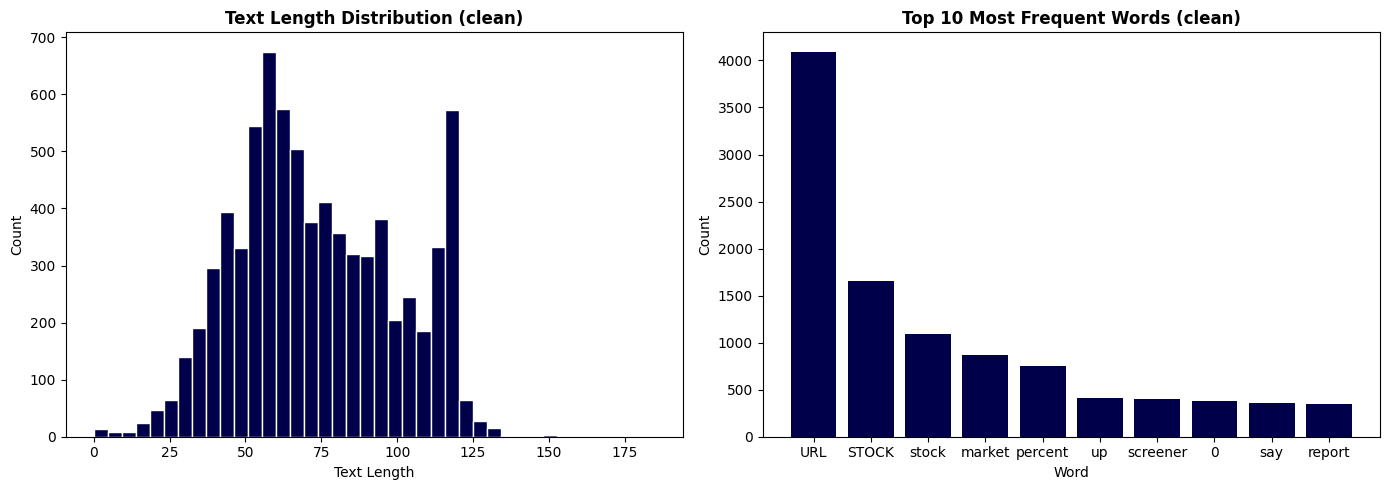

In [12]:
train["text_clean_joined"] = train['text_tokens'].apply(lambda x: " ".join(x))
validation["text_clean_joined"] = validation['text_tokens'].apply(lambda x: " ".join(x))

freq_clean = pd.Series(' '.join(train['text_clean_joined']).split()).value_counts()

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))
ax[0].hist(
         train.text_clean.str.len(),
         bins=40,
         color="#00004A",
         edgecolor="white"
         )
ax[1].bar(freq_clean.head(10).index, freq_clean.head(10).values, color="#00004A")

ax[0].set_xlabel("Text Length")
ax[0].set_ylabel("Count")
ax[0].set_title("Text Length Distribution (clean)", fontweight="bold")
ax[1].set_xlabel("Word")
ax[1].set_ylabel("Count")
ax[1].set_title("Top 10 Most Frequent Words (clean)", fontweight="bold")
plt.tight_layout()
plt.savefig(r"plots/clean_distributions.png")
plt.show()

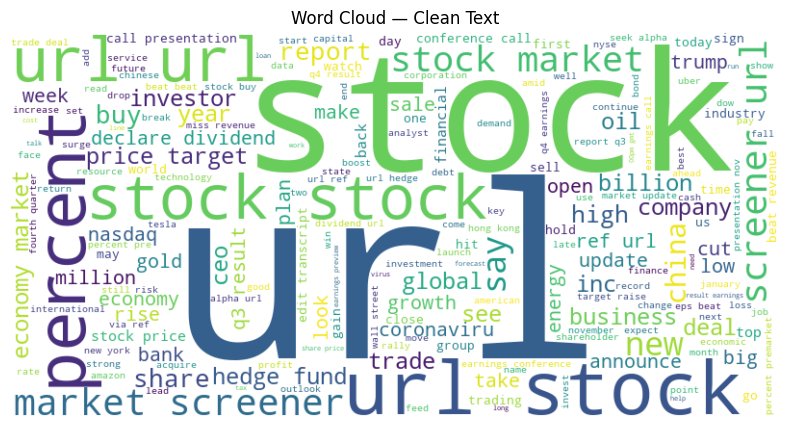

In [13]:
raw_text = ' '.join(train["text_clean_joined"]).lower()
raw_wc = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Clean Text')
plt.savefig(r"plots/clean_wordcloud.png")
plt.show()

### Encoding

In [14]:
train_bow, bow_encoder = encode_bow(train["text_tokens"], min_df=30)

w2v_encoder = train_word2vec_model(train["text_tokens"], vector_size=35)
train_vec = encode_w2v(train["text_tokens"], w2v_encoder)

tokenizer, model, device = load_model()
train_trans = encode_trans(train["text_clean_joined"], tokenizer, model, device)

train_label = train["label"]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6171.93it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
validation_bow = encode_bow(validation["text_tokens"], 
                            encoder=bow_encoder, 
                            return_bow=False)
validation_vec = encode_w2v(validation["text_tokens"], w2v_encoder)
validation_trans = encode_trans(validation["text_clean_joined"], tokenizer, model, device)

validation_label = validation["label"]

### Encoding Visualisations

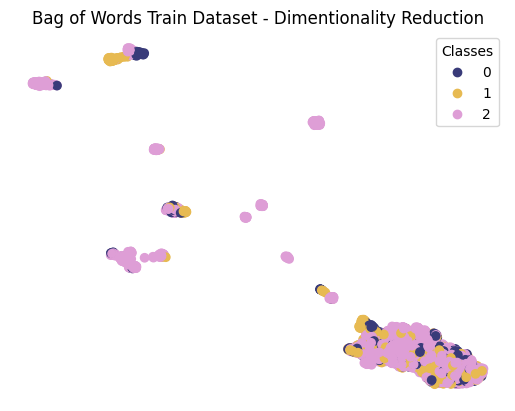

In [16]:
umap_object = umap.UMAP(n_neighbors=50, min_dist=0.9, random_state=SEED) 
umap_embedding = umap_object.fit_transform(train_bow)
visualize_dimensionality_reduction(umap_embedding, 
                                   train_label, 
                                   save_to=r"plots/bow_umap.png",
                                   title="Bag of Words Train Dataset - Dimentionality Reduction")

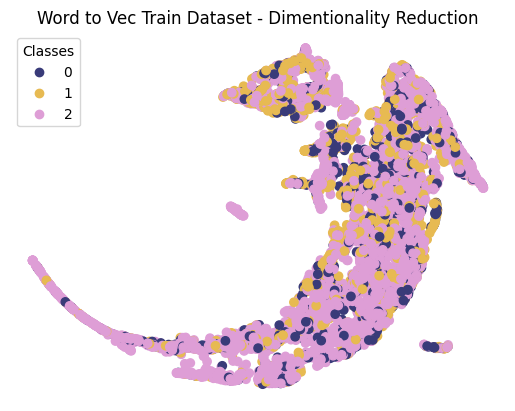

In [17]:
umap_object = umap.UMAP(n_neighbors=50, min_dist=0.1, random_state=SEED) 
umap_embedding = umap_object.fit_transform(train_vec)
visualize_dimensionality_reduction(umap_embedding, 
                                   train_label,
                                   save_to=r"plots/w2v_umap.png",
                                   title="Word to Vec Train Dataset - Dimentionality Reduction")

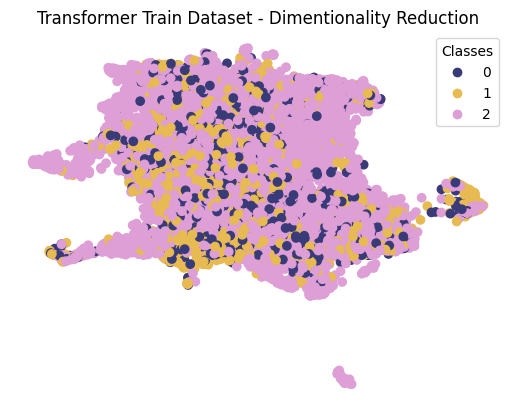

In [18]:
umap_object = umap.UMAP(n_neighbors=50, min_dist=0.1, random_state=SEED) 
umap_embedding = umap_object.fit_transform(train_trans)
visualize_dimensionality_reduction(umap_embedding, 
                                   train_label,
                                   save_to=r"plots/trans_umap.png",
                                   title="Transformer Train Dataset - Dimentionality Reduction")

# Training

## BOW Data

### KNN

In [19]:
best_score = -float("inf")
grid = {
        "n_neighbors": [*range(1, 16, 2)],
        "weights": ["uniform", "distance"],
        "p": [1, 2, 3]
        }

for g in tqdm.tqdm(ParameterSampler(grid, n_iter=30, random_state=SEED)):
    _knn = KNeighborsClassifier()
    _knn.set_params(**g)
    _knn.fit(train_bow, train_label)

    new_score = recall_score(validation_label, 
                             _knn.predict(validation_bow), 
                             average="macro")
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print("Best Recall: %0.5f" % best_score )
print("Grid:", best_grid)

100%|██████████| 30/30 [02:36<00:00,  5.20s/it]

Best Recall: 0.60270
Grid: {'weights': 'distance', 'p': 2, 'n_neighbors': 3}


In [20]:
knn_classifier = KNeighborsClassifier()\
                .set_params(**best_grid)\
                .fit(train_bow, train_label)
knn_predicted = knn_classifier.predict(validation_bow)
knn_cm = confusion_matrix(validation_label, knn_predicted, normalize="true")

print(classification_report(validation_label, 
                            knn_predicted, 
                            target_names=("Bearish", "Bullish", "Neutral")))

              precision    recall  f1-score   support

     Bearish       0.55      0.39      0.45       288
     Bullish       0.69      0.51      0.59       385
     Neutral       0.79      0.91      0.85      1236

    accuracy                           0.75      1909
   macro avg       0.68      0.60      0.63      1909
weighted avg       0.73      0.75      0.74      1909



### Tree

In [21]:
best_score = -float("inf")
grid = {
        "n_estimators":[*range(10, 251, 10)], 
        "criterion":["gini", "entropy"],
        "max_depth":[*range(1, 11)],
        "min_samples_split":[2**p for p in range(1, 11)],
        "min_samples_leaf":[2**p for p in range(0, 11)],
        "max_features":["sqrt", "log2", 1],
        }

for g in tqdm.tqdm(ParameterSampler(grid, n_iter=30, random_state=SEED)):
    _rf = RandomForestClassifier()
    _rf.set_params(**g)
    _rf.fit(train_bow, train_label)

    new_score = recall_score(validation_label, 
                             _rf.predict(validation_bow), 
                             average="macro")
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print("Best Recall: %0.5f" % best_score )
print("Grid:", best_grid)

100%|██████████| 30/30 [00:09<00:00,  3.14it/s]

Best Recall: 0.37037
Grid: {'n_estimators': 40, 'min_samples_split': 2, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'max_depth': 9, 'criterion': 'entropy'}


In [22]:
rf_classifier = RandomForestClassifier()\
                .set_params(**best_grid)\
                .fit(train_bow, train_label)

rf_predicted = rf_classifier.predict(validation_bow)
rf_cm = confusion_matrix(validation_label, rf_predicted, normalize="true")

print(classification_report(validation_label, 
                            rf_predicted, 
                            target_names=("Bearish", "Bullish", "Neutral")))

              precision    recall  f1-score   support

     Bearish       0.00      0.00      0.00       288
     Bullish       0.91      0.13      0.23       385
     Neutral       0.67      1.00      0.80      1236

    accuracy                           0.67      1909
   macro avg       0.53      0.38      0.34      1909
weighted avg       0.61      0.67      0.56      1909



### Compare

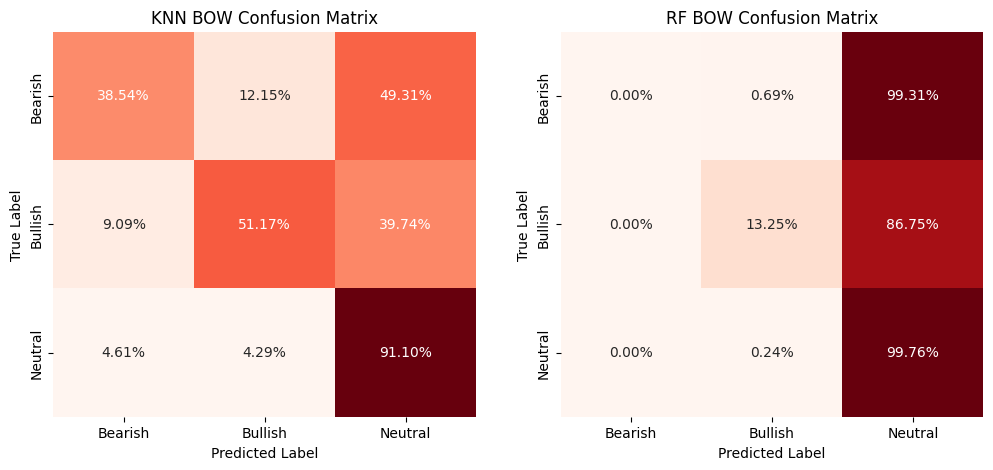

In [23]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

sns.heatmap(knn_cm,
            cmap="Reds",
            cbar=False,
            annot=True,
            fmt=".2%",
            xticklabels=("Bearish", "Bullish", "Neutral"), 
            yticklabels=("Bearish", "Bullish", "Neutral"),
            ax=ax[0]
            )
ax[0].set_title("KNN BOW Confusion Matrix")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")

sns.heatmap(rf_cm,
            cmap="Reds",
            cbar=False,
            annot=True,
            fmt=".2%",
            xticklabels=("Bearish", "Bullish", "Neutral"), 
            yticklabels=("Bearish", "Bullish", "Neutral"),
            ax=ax[1]
            )
ax[1].set_title("RF BOW Confusion Matrix")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.savefig("plots/bow_compare.png")
plt.show()

## Word2Vec

### KNN

In [24]:
best_score = -float("inf")
grid = {
        "n_neighbors": [*range(1, 16, 2)],
        "weights": ["uniform", "distance"],
        "p": [1, 2, 3]
        }

for g in tqdm.tqdm(ParameterSampler(grid, n_iter=30, random_state=SEED)):
    _knn = KNeighborsClassifier()
    _knn.set_params(**g)
    _knn.fit(train_vec, train_label)

    new_score = recall_score(validation_label, 
                             _knn.predict(validation_vec), 
                             average="macro")
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print("Best Recall: %0.5f" % best_score )
print("Grid:", best_grid)

100%|██████████| 30/30 [00:42<00:00,  1.42s/it]

Best Recall: 0.45850
Grid: {'weights': 'distance', 'p': 2, 'n_neighbors': 3}


In [25]:
knn_classifier = KNeighborsClassifier()\
                .set_params(**best_grid)\
                .fit(train_vec, train_label)
knn_predicted = knn_classifier.predict(validation_vec)
knn_cm = confusion_matrix(validation_label, knn_predicted, normalize="true")

print(classification_report(validation_label, 
                            knn_predicted, 
                            target_names=("Bearish", "Bullish", "Neutral")))

              precision    recall  f1-score   support

     Bearish       0.26      0.19      0.22       288
     Bullish       0.41      0.37      0.39       385
     Neutral       0.74      0.81      0.78      1236

    accuracy                           0.63      1909
   macro avg       0.47      0.46      0.46      1909
weighted avg       0.60      0.63      0.62      1909



### Tree

In [26]:
best_score = -float("inf")
grid = {
        "n_estimators":[*range(10, 251, 10)], 
        "criterion":["gini", "entropy"],
        "max_depth":[*range(1, 11)],
        "min_samples_split":[2**p for p in range(1, 11)],
        "min_samples_leaf":[2**p for p in range(0, 11)],
        "max_features":["sqrt", "log2", 1],
        }

for g in tqdm.tqdm(ParameterSampler(grid, n_iter=30, random_state=SEED)):
    _rf = RandomForestClassifier()
    _rf.set_params(**g)
    _rf.fit(train_vec, train_label)

    new_score = recall_score(validation_label, 
                             _rf.predict(validation_vec), 
                             average="macro")
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print("Best Recall: %0.5f" % best_score )
print("Grid:", best_grid)

100%|██████████| 30/30 [00:35<00:00,  1.18s/it]

Best Recall: 0.44522
Grid: {'n_estimators': 160, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'entropy'}


In [27]:
rf_classifier = RandomForestClassifier()\
                .set_params(**best_grid)\
                .fit(train_vec, train_label)

rf_predicted = rf_classifier.predict(validation_vec)
rf_cm = confusion_matrix(validation_label, rf_predicted, normalize="true")

print(classification_report(validation_label, 
                            rf_predicted, 
                            target_names=("Bearish", "Bullish", "Neutral")))

              precision    recall  f1-score   support

     Bearish       0.50      0.02      0.03       288
     Bullish       0.56      0.34      0.42       385
     Neutral       0.71      0.95      0.81      1236

    accuracy                           0.69      1909
   macro avg       0.59      0.44      0.42      1909
weighted avg       0.65      0.69      0.62      1909



### Compare

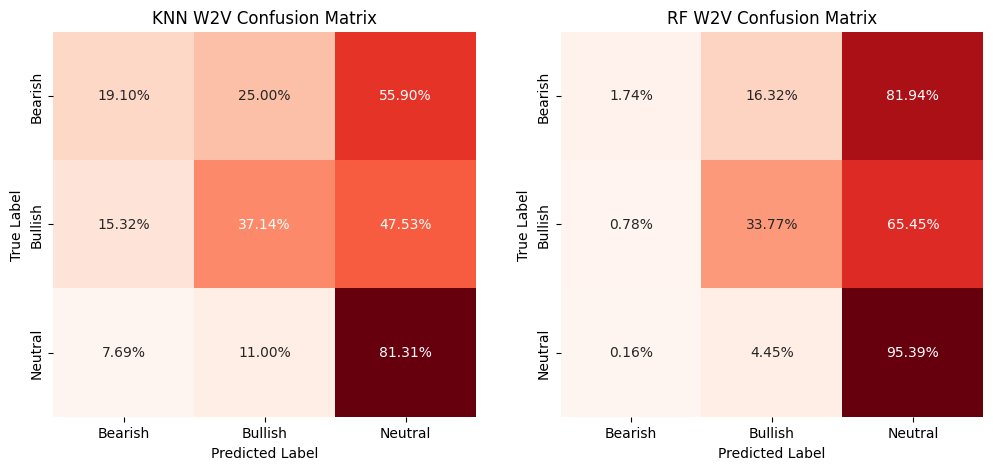

In [28]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

sns.heatmap(knn_cm,
            cmap="Reds",
            cbar=False,
            annot=True,
            fmt=".2%",
            xticklabels=("Bearish", "Bullish", "Neutral"), 
            yticklabels=("Bearish", "Bullish", "Neutral"),
            ax=ax[0]
            )
ax[0].set_title("KNN W2V Confusion Matrix")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")

sns.heatmap(rf_cm,
            cmap="Reds",
            cbar=False,
            annot=True,
            fmt=".2%",
            xticklabels=("Bearish", "Bullish", "Neutral"), 
            yticklabels=("Bearish", "Bullish", "Neutral"),
            ax=ax[1]
            )
ax[1].set_title("RF W2V Confusion Matrix")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.savefig("plots/w2v_compare.png")
plt.show()

## Transformers

### KNN

In [29]:
best_score = -float("inf")
grid = {
        "n_neighbors": [*range(1, 16, 2)],
        "weights": ["uniform", "distance"],
        "p": [1, 2, 3]
        }

for g in tqdm.tqdm(ParameterSampler(grid, n_iter=30, random_state=SEED)):
    _knn = KNeighborsClassifier()
    _knn.set_params(**g)
    _knn.fit(train_trans, train_label)

    new_score = recall_score(validation_label, 
                             _knn.predict(validation_trans), 
                             average="macro")
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print("Best Recall: %0.5f" % best_score )
print("Grid:", best_grid)

100%|██████████| 30/30 [14:46<00:00, 29.55s/it]

Best Recall: 0.60388
Grid: {'weights': 'uniform', 'p': 1, 'n_neighbors': 5}


In [30]:
knn_classifier = KNeighborsClassifier()\
                .set_params(**best_grid)\
                .fit(train_trans, train_label)
knn_predicted = knn_classifier.predict(validation_trans)
knn_cm = confusion_matrix(validation_label, knn_predicted, normalize="true")

print(classification_report(validation_label, 
                            knn_predicted, 
                            target_names=("Bearish", "Bullish", "Neutral")))

              precision    recall  f1-score   support

     Bearish       0.42      0.47      0.44       288
     Bullish       0.51      0.55      0.53       385
     Neutral       0.84      0.79      0.81      1236

    accuracy                           0.69      1909
   macro avg       0.59      0.60      0.59      1909
weighted avg       0.71      0.69      0.70      1909



### Tree

In [31]:
best_score = -float("inf")
grid = {
        "n_estimators":[*range(10, 251, 10)], 
        "criterion":["gini", "entropy"],
        "max_depth":[*range(1, 11)],
        "min_samples_split":[2**p for p in range(1, 11)],
        "min_samples_leaf":[2**p for p in range(0, 11)],
        "max_features":["sqrt", "log2", 1],
        }

for g in tqdm.tqdm(ParameterSampler(grid, n_iter=30, random_state=SEED)):
    _rf = RandomForestClassifier()
    _rf.set_params(**g)
    _rf.fit(train_trans, train_label)

    new_score = recall_score(validation_label, 
                             _rf.predict(validation_trans), 
                             average="macro")
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print("Best Recall: %0.5f" % best_score )
print("Grid:", best_grid)

100%|██████████| 30/30 [01:32<00:00,  3.08s/it]

Best Recall: 0.38579
Grid: {'n_estimators': 40, 'min_samples_split': 2, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'max_depth': 9, 'criterion': 'entropy'}


In [32]:
rf_classifier = RandomForestClassifier()\
                .set_params(**best_grid)\
                .fit(train_trans, train_label)

rf_predicted = rf_classifier.predict(validation_trans)
rf_cm = confusion_matrix(validation_label, rf_predicted, normalize="true")

print(classification_report(validation_label, 
                            rf_predicted, 
                            target_names=("Bearish", "Bullish", "Neutral")))

              precision    recall  f1-score   support

     Bearish       0.83      0.02      0.03       288
     Bullish       0.68      0.13      0.21       385
     Neutral       0.67      1.00      0.80      1236

    accuracy                           0.67      1909
   macro avg       0.73      0.38      0.35      1909
weighted avg       0.70      0.67      0.57      1909



### Compare

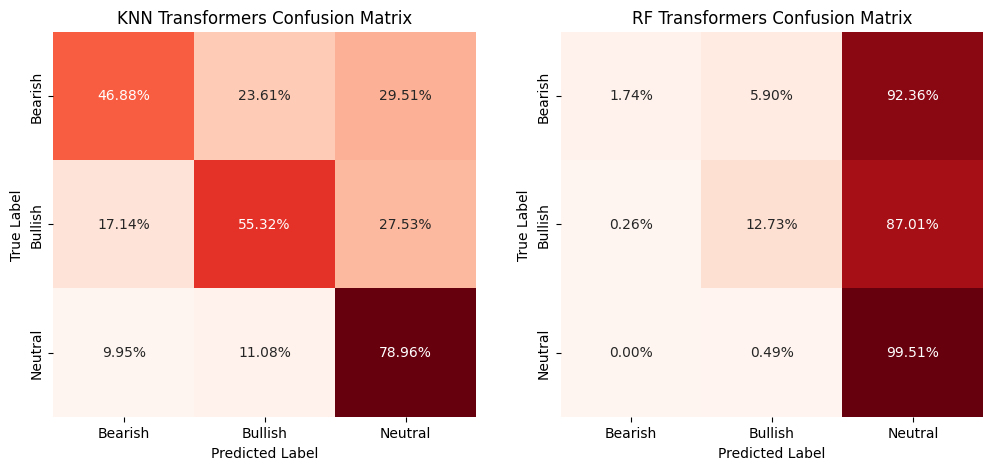

In [33]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

sns.heatmap(knn_cm,
            cmap="Reds",
            cbar=False,
            annot=True,
            fmt=".2%",
            xticklabels=("Bearish", "Bullish", "Neutral"), 
            yticklabels=("Bearish", "Bullish", "Neutral"),
            ax=ax[0]
            )
ax[0].set_title("KNN Transformers Confusion Matrix")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")

sns.heatmap(rf_cm,
            cmap="Reds",
            cbar=False,
            annot=True,
            fmt=".2%",
            xticklabels=("Bearish", "Bullish", "Neutral"), 
            yticklabels=("Bearish", "Bullish", "Neutral"),
            ax=ax[1]
            )
ax[1].set_title("RF Transformers Confusion Matrix")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.savefig("plots/trans_compare.png")
plt.show()